# 02 — Empirical Tests

**Input:** `../data/cleaned_responses.csv` (output of `01_clean.ipynb`)  
**Outputs:** printed results + `../figures/*.png`

Tests the four predictions from `EGT_Project.pdf` §*Testable Predictions* on the 42-response survey:

| # | Prediction | Test |
|---|---|---|
| 1 | Higher GPA importance `w` → higher layup ratio `s` | OLS `s ~ w + C(year) + C(major)`, HC1 SEs; sign of β_w |
| 2 | `s` should be ordered pre-med > finance > tech/grad > undecided | OLS `s ~ C(track)`, F-test + track coefficients |
| 3 | Students who avoided a course for GPA show higher `s`, `w` | One-sided Mann–Whitney on Q7 groups |
| 4 | Students perceiving environmental pressure (Q9) show higher `s` | Spearman ρ(q9, s) |

**Robustness:** P1 is re-run dropping `is_double=True` rows.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

DATA = "../data/cleaned_responses.csv"
FIGDIR = "../figures"

df = pd.read_csv(DATA)
print(f"Loaded {len(df)} rows from {DATA}")
df.head()

Loaded 42 rows from ../data/cleaned_responses.csv


,timestamp,year,major,major_raw,is_double,track,courses,layups,s,gpa_importance,w,q7_avoided,q7_score,q9_env,q9_score,strategy_self,strategy_self_missing,q10_counterfactual,q10_missing
0,5/7/2026 13:27:53,28,Mathematics,Mathematics,False,Tech/engineering,9,1,0.111111,Very important,4,Never,0,Neutral,0,"I choose based on genuine interest, regardless...",False,Would not change,False
1,5/10/2026 11:30:06,27,Economics,"Economics modified with Computer Science, Germ...",False,Finance/consulting,9,5,0.555556,Very important,4,Never,0,Strongly yes,2,"I lean toward expected grade, with interest as...",False,It would not change.,False
2,5/10/2026 11:30:28,29,Economics,Economics,False,Finance/consulting,9,2,0.222222,Very important,4,"Yes, once or twice",1,Strongly yes,2,I choose almost entirely based on expected gra...,False,I would take more interesting classes that ben...,False
3,5/10/2026 11:30:53,27,Government,Gov and Econ double major,True,Finance/consulting,9,2,0.222222,Moderately important,3,Never,0,Somewhat yes,1,"I choose based on genuine interest, regardless...",False,I wouldn’t,False
4,5/10/2026 11:32:18,28,Computer Science,Computer Science,False,Finance/consulting,9,4,0.444444,Very important,4,"Yes, once or twice",1,Somewhat yes,1,"I lean toward expected grade, with interest as...",False,If there were no enforced medians (or they wer...,False


## Descriptives

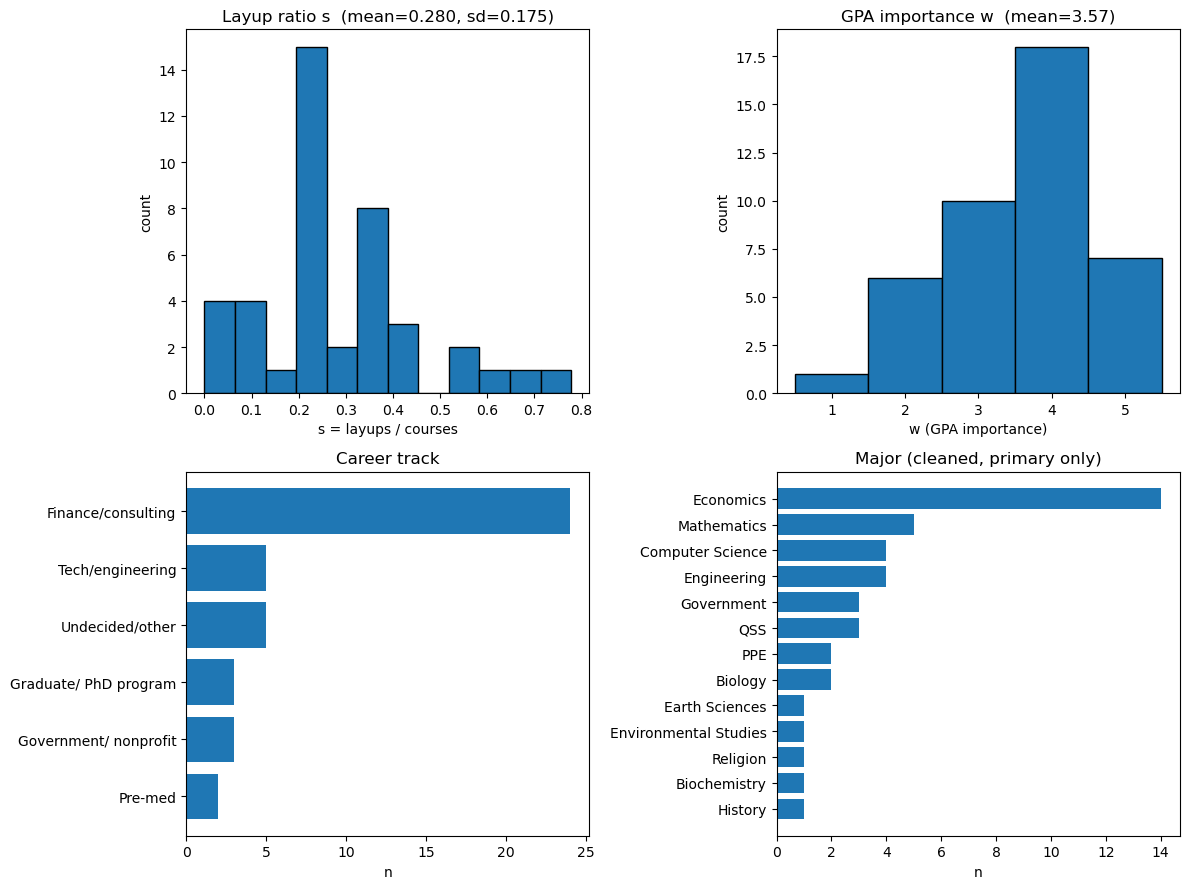

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(df["s"].dropna(), bins=12, edgecolor="black")
axes[0, 0].set_xlabel("s = layups / courses")
axes[0, 0].set_ylabel("count")
axes[0, 0].set_title(f"Layup ratio s  (mean={df['s'].mean():.3f}, sd={df['s'].std():.3f})")

axes[0, 1].hist(df["w"].dropna(), bins=np.arange(0.5, 6.5, 1), edgecolor="black")
axes[0, 1].set_xlabel("w (GPA importance)")
axes[0, 1].set_ylabel("count")
axes[0, 1].set_title(f"GPA importance w  (mean={df['w'].mean():.2f})")
axes[0, 1].set_xticks(range(1, 6))

tc = df["track"].value_counts()
axes[1, 0].barh(tc.index, tc.values)
axes[1, 0].set_xlabel("n")
axes[1, 0].set_title("Career track")
axes[1, 0].invert_yaxis()

mc = df["major"].value_counts()
axes[1, 1].barh(mc.index, mc.values)
axes[1, 1].set_xlabel("n")
axes[1, 1].set_title("Major (cleaned, primary only)")
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{FIGDIR}/desc_overview.png", dpi=120, bbox_inches="tight")
plt.show()

In [3]:
print("Mean s and w by track:")
print(df.groupby("track").agg(n=("s", "count"), s_mean=("s", "mean"),
                              s_sd=("s", "std"), w_mean=("w", "mean")).round(3))
print("\nMean s by major (n>=2 shown):")
agg = df.groupby("major").agg(n=("s", "count"), s_mean=("s", "mean")).round(3)
print(agg[agg["n"] >= 2].sort_values("s_mean", ascending=False))

Mean s and w by track:
                        n  s_mean   s_sd  w_mean
track                                           
Finance/consulting     24   0.350  0.167   3.667
Government/ nonprofit   3   0.233  0.096   4.000
Graduate/ PhD program   3   0.148  0.128   3.000
Pre-med                 2   0.100  0.141   4.500
Tech/engineering        5   0.220  0.204   3.000
Undecided/other         5   0.183  0.130   3.400

Mean s by major (n>=2 shown):
                   n  s_mean
major                       
PPE                2   0.411
Computer Science   4   0.359
Economics         14   0.339
QSS                3   0.270
Government         3   0.231
Mathematics        5   0.200
Biology            2   0.167
Engineering        4   0.139


## Prediction 1 — OLS  $s_i = \alpha + \beta_w w_i + \text{year FE} + \text{major FE} + \varepsilon_i$

Paper predicts $\partial s^\ast / \partial w = 1/\gamma > 0$, so $\beta_w > 0$.

In [4]:
df_ols = df.dropna(subset=["s", "w", "year", "major"]).copy()
df_ols["year"] = df_ols["year"].astype(int)
model = smf.ols("s ~ w + C(year) + C(major)", data=df_ols).fit(cov_type="HC1")
print(model.summary())

beta_w = model.params["w"]
ci = model.conf_int().loc["w"]
p_w = model.pvalues["w"]
print(f"\n>>> beta_w = {beta_w:+.4f}   95% CI = [{ci[0]:+.4f}, {ci[1]:+.4f}]   p = {p_w:.4f}")
if beta_w != 0:
    print(f">>> Implied gamma_hat = 1/beta_w = {1/beta_w:.2f}")
print(f">>> Sign matches paper prediction (positive)? {'YES' if beta_w > 0 else 'NO'}")

                            OLS Regression Results                            
Dep. Variable:                      s   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                 -0.246
Method:                 Least Squares   F-statistic:                     1.248
Date:                Mon, 18 May 2026   Prob (F-statistic):              0.307
Time:                        14:38:20   Log-Likelihood:                 19.884
No. Observations:                  42   AIC:                            -5.767
Df Residuals:                      25   BIC:                             23.77
Df Model:                          16                                         
Covariance Type:                  HC1                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

c:\Users\sharp\miniforge3\envs\qss30.04\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 12
  warnings.warn('covariance of constraints does not have full '


In [5]:
df_robust = df_ols[~df_ols["is_double"]].copy()
print(f"Dropped {len(df_ols) - len(df_robust)} double-major rows (n: {len(df_ols)} -> {len(df_robust)})")
model_r = smf.ols("s ~ w + C(year) + C(major)", data=df_robust).fit(cov_type="HC1")
beta_w_r = model_r.params["w"]
print(f"beta_w (full sample):       {beta_w:+.4f}")
print(f"beta_w (no double-majors):  {beta_w_r:+.4f}")
print(f"Sign stable? {'YES' if np.sign(beta_w) == np.sign(beta_w_r) else 'NO'}")

Dropped 6 double-major rows (n: 42 -> 36)
beta_w (full sample):       +0.0103
beta_w (no double-majors):  +0.0514
Sign stable? YES


## Prediction 2 — Cross-track distribution of s

Paper expects $s^\ast(w)$ ordering: **pre-med > finance > tech/grad > undecided**.

Test: OLS `s ~ C(track)` with undecided as the baseline. A significant F-test indicates tracks differ; coefficient signs should match the predicted ordering.

In [6]:
track_stats = df.dropna(subset=["s", "track"]).groupby("track").agg(
    n=("s", "count"), s_mean=("s", "mean"), s_median=("s", "median"), w_mean=("w", "mean")
).round(3).sort_values("s_mean", ascending=False)
print("Track-level summary (sorted by mean s, descending):")
print(track_stats)

df_p2 = df.dropna(subset=["s", "track"]).copy()
model_p2 = smf.ols("s ~ C(track, Treatment(reference='Undecided/other'))", data=df_p2).fit(cov_type="HC1")
print("\nOLS: s ~ C(track), baseline = Undecided/other")
print(model_p2.summary())

f_stat = model_p2.fvalue
f_pval = model_p2.f_pvalue
print(f"\n>>> F-statistic = {f_stat:.3f}, p = {f_pval:.4f}")
print("\nTrack coefficients vs Undecided/other (positive = higher s):")
for name, coef in model_p2.params.items():
    if "track" in name:
        p_val = model_p2.pvalues[name]
        print(f"  {name}: {coef:+.4f}  (p={p_val:.3f})")

Track-level summary (sorted by mean s, descending):
                        n  s_mean  s_median  w_mean
track                                              
Finance/consulting     24   0.350     0.333   3.667
Government/ nonprofit   3   0.233     0.222   4.000
Tech/engineering        5   0.220     0.222   3.000
Undecided/other         5   0.183     0.222   3.400
Graduate/ PhD program   3   0.148     0.222   3.000
Pre-med                 2   0.100     0.100   4.500

OLS: s ~ C(track), baseline = Undecided/other
                            OLS Regression Results                            
Dep. Variable:                      s   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     3.134
Date:                Mon, 18 May 2026   Prob (F-statistic):             0.0189
Time:                        14:38:24   Log-Likelihood:                 20.006
No. Observa

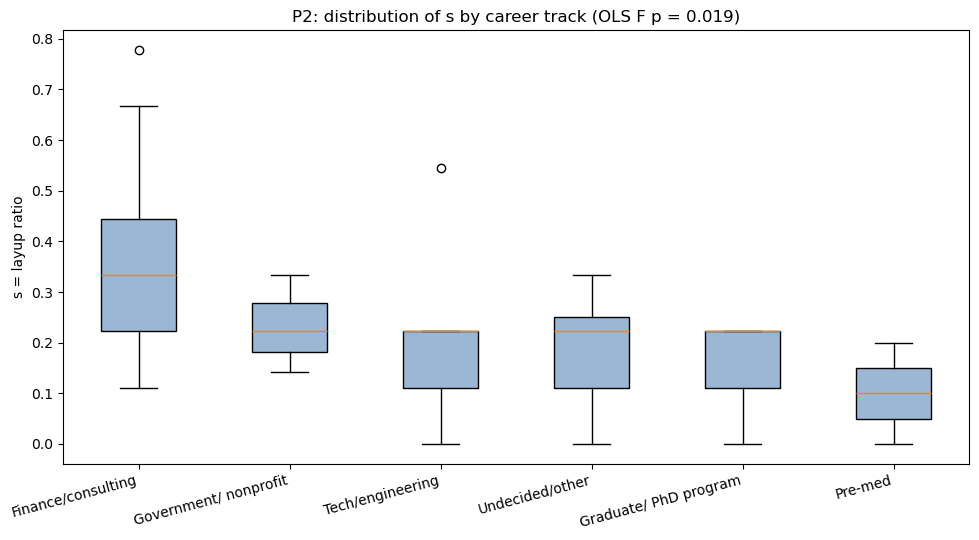

In [7]:
order = track_stats.index.tolist()
fig, ax = plt.subplots(figsize=(10, 5.5))
data = [df[df["track"] == t]["s"].dropna().values for t in order]
bp = ax.boxplot(data, tick_labels=order, vert=True, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#9bb7d4")
ax.set_ylabel("s = layup ratio")
ax.set_title(f"P2: distribution of s by career track (OLS F p = {f_pval:.3f})")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/p2_box_s_by_track.png", dpi=120, bbox_inches="tight")
plt.show()

## Prediction 3 — Q7-conditional means

Students who avoided/dropped a course to protect GPA (`q7_score ≥ 1`) should show **higher s and w**.

In [8]:
df_q7 = df.dropna(subset=["s", "q7_score", "w"]).copy()
avoided = df_q7[df_q7["q7_score"] >= 1]
never = df_q7[df_q7["q7_score"] == 0]

p3_results = {}
for var in ["s", "w"]:
    a_mean, n_mean = avoided[var].mean(), never[var].mean()
    u = stats.mannwhitneyu(avoided[var], never[var], alternative="greater")
    p3_results[var] = (a_mean, n_mean, u.pvalue)
    print(f"{var}: E[{var}|avoided] = {a_mean:.3f} (n={len(avoided)})   "
          f"E[{var}|never] = {n_mean:.3f} (n={len(never)})   diff = {a_mean - n_mean:+.3f}")
    print(f"     Mann-Whitney (one-sided, avoided > never): U = {u.statistic:.1f}, p = {u.pvalue:.4f}")

s: E[s|avoided] = 0.302 (n=18)   E[s|never] = 0.264 (n=24)   diff = +0.038
     Mann-Whitney (one-sided, avoided > never): U = 253.0, p = 0.1733
w: E[w|avoided] = 3.778 (n=18)   E[w|never] = 3.417 (n=24)   diff = +0.361
     Mann-Whitney (one-sided, avoided > never): U = 251.5, p = 0.1743


## Prediction 4 — Q9 correlation with s

Students who perceive that the environment pushes toward easier courses (`q9_score` high) should show higher `s` — consistent with high $\gamma$ perception.

Spearman rho = +0.231, p = 0.1402  (n = 42)
Sign matches paper prediction (positive)? YES


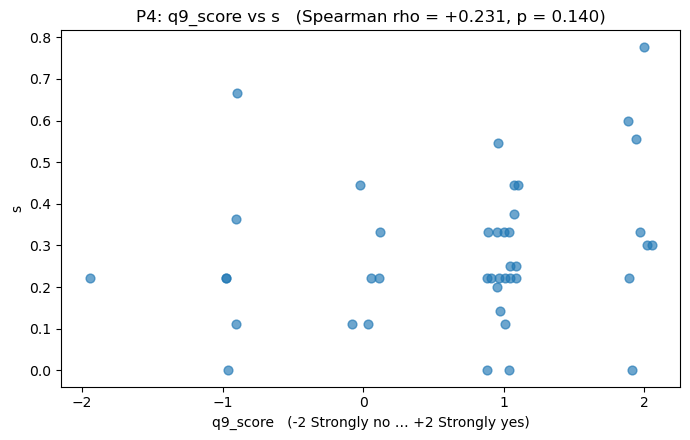

In [9]:
df_q9 = df.dropna(subset=["s", "q9_score"]).copy()
rho, p_q9 = stats.spearmanr(df_q9["q9_score"], df_q9["s"])
print(f"Spearman rho = {rho:+.3f}, p = {p_q9:.4f}  (n = {len(df_q9)})")
print(f"Sign matches paper prediction (positive)? {'YES' if rho > 0 else 'NO'}")

fig, ax = plt.subplots(figsize=(7, 4.5))
rng = np.random.default_rng(0)
jitter_x = rng.uniform(-0.12, 0.12, len(df_q9))
ax.scatter(df_q9["q9_score"] + jitter_x, df_q9["s"], alpha=0.65, s=40)
ax.set_xlabel("q9_score   (-2 Strongly no … +2 Strongly yes)")
ax.set_ylabel("s")
ax.set_title(f"P4: q9_score vs s   (Spearman rho = {rho:+.3f}, p = {p_q9:.3f})")
ax.set_xticks(range(-2, 3))
plt.tight_layout()
plt.savefig(f"{FIGDIR}/p4_scatter_q9_s.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary

In [10]:
summary = pd.DataFrame([
    {"prediction": "P1: beta_w > 0 (OLS)",
     "statistic": f"beta_w = {beta_w:+.4f}",
     "p_value": f"{p_w:.4f}",
     "direction_ok": beta_w > 0},
    {"prediction": "P1 robustness (drop doubles)",
     "statistic": f"beta_w = {beta_w_r:+.4f}",
     "p_value": f"{model_r.pvalues['w']:.4f}",
     "direction_ok": beta_w_r > 0},
    {"prediction": "P2: s differs across tracks (OLS F-test)",
     "statistic": f"F = {f_stat:.3f}",
     "p_value": f"{f_pval:.4f}",
     "direction_ok": None},
    {"prediction": "P3a: E[s | avoided] > E[s | never]",
     "statistic": f"diff = {p3_results['s'][0] - p3_results['s'][1]:+.3f}",
     "p_value": f"{p3_results['s'][2]:.4f}",
     "direction_ok": p3_results['s'][0] > p3_results['s'][1]},
    {"prediction": "P3b: E[w | avoided] > E[w | never]",
     "statistic": f"diff = {p3_results['w'][0] - p3_results['w'][1]:+.3f}",
     "p_value": f"{p3_results['w'][2]:.4f}",
     "direction_ok": p3_results['w'][0] > p3_results['w'][1]},
    {"prediction": "P4: Spearman(q9, s) > 0",
     "statistic": f"rho = {rho:+.3f}",
     "p_value": f"{p_q9:.4f}",
     "direction_ok": rho > 0},
])
print(summary.to_string(index=False))

                              prediction        statistic p_value direction_ok
                    P1: beta_w > 0 (OLS) beta_w = +0.0103  0.8279         True
            P1 robustness (drop doubles) beta_w = +0.0514  0.4699         True
P2: s differs across tracks (OLS F-test)        F = 3.134  0.0189         None
      P3a: E[s | avoided] > E[s | never]    diff = +0.038  0.1733         True
      P3b: E[w | avoided] > E[w | never]    diff = +0.361  0.1743         True
                 P4: Spearman(q9, s) > 0     rho = +0.231  0.1402         True
